In [ ]:
!pip install torchinfo

In [ ]:
import torch
import torch.nn as nn

In [ ]:
cfgs = {
    'A': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'B': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'D': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'],
    'E': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M'],
}

In [ ]:
class VGG(nn.Module):

    def __init__(self, cfg, batch_norm, num_classes=1000, init_weights=True):
        super(VGG, self).__init__()
        self.features = self.make_layers(cfg, batch_norm)
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7)) # 7x7 avg poolng (flatten 노드 개수 통일을 위해 adaptive pooling 사용)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )
        if init_weights:
            self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def make_layers(self, cfg, batch_norm=False):
        layers = []
        in_channels = 3
        for v in cfg:
            if v == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
                if batch_norm:
                    layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
                else:
                    layers += [conv2d, nn.ReLU(inplace=True)]
                in_channels = v
        return nn.Sequential(*layers)


In [ ]:
from torchinfo import summary

model_vgg16_bn = VGG(cfgs["D"], batch_norm=True)
summary(model_vgg16_bn, input_size=(2,3,224,224), device='cpu')


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [2, 1000]                 --
├─Sequential: 1-1                        [2, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [2, 64, 224, 224]         1,792
│    └─BatchNorm2d: 2-2                  [2, 64, 224, 224]         128
│    └─ReLU: 2-3                         [2, 64, 224, 224]         --
│    └─Conv2d: 2-4                       [2, 64, 224, 224]         36,928
│    └─BatchNorm2d: 2-5                  [2, 64, 224, 224]         128
│    └─ReLU: 2-6                         [2, 64, 224, 224]         --
│    └─MaxPool2d: 2-7                    [2, 64, 112, 112]         --
│    └─Conv2d: 2-8                       [2, 128, 112, 112]        73,856
│    └─BatchNorm2d: 2-9                  [2, 128, 112, 112]        256
│    └─ReLU: 2-10                        [2, 128, 112, 112]        --
│    └─Conv2d: 2-11                      [2, 128, 112, 112]        147,

In [ ]:
model_vgg19_bn = VGG(cfgs["E"], batch_norm=True)
summary(model_vgg16_bn, input_size=(2,3,224,224), device='cpu')


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [2, 1000]                 --
├─Sequential: 1-1                        [2, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [2, 64, 224, 224]         1,792
│    └─BatchNorm2d: 2-2                  [2, 64, 224, 224]         128
│    └─ReLU: 2-3                         [2, 64, 224, 224]         --
│    └─Conv2d: 2-4                       [2, 64, 224, 224]         36,928
│    └─BatchNorm2d: 2-5                  [2, 64, 224, 224]         128
│    └─ReLU: 2-6                         [2, 64, 224, 224]         --
│    └─MaxPool2d: 2-7                    [2, 64, 112, 112]         --
│    └─Conv2d: 2-8                       [2, 128, 112, 112]        73,856
│    └─BatchNorm2d: 2-9                  [2, 128, 112, 112]        256
│    └─ReLU: 2-10                        [2, 128, 112, 112]        --
│    └─Conv2d: 2-11                      [2, 128, 112, 112]        147,

## 사전 훈련된 모델 활용
- 파이토치 : https://pytorch.org/vision/main/models.html#table-of-all-available-classification-weights
- VGG-16 with ImageNet & BN : https://pytorch.org/vision/main/models/generated/torchvision.models.vgg16_bn.html#torchvision.models.VGG16_BN_Weights

- 데이터 : https://www.microsoft.com/en-US/download/details.aspx?id=54765

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
# model = torchvision.models.vgg16_bn(pretrained=True)
model = torchvision.models.vgg16_bn(weights='VGG16_BN_Weights.IMAGENET1K_V1')
model

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth
100%|██████████| 528M/528M [00:06<00:00, 82.1MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

In [ ]:
summary(model, input_size=(2,3,224,224), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [2, 1000]                 --
├─Sequential: 1-1                        [2, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [2, 64, 224, 224]         1,792
│    └─BatchNorm2d: 2-2                  [2, 64, 224, 224]         128
│    └─ReLU: 2-3                         [2, 64, 224, 224]         --
│    └─Conv2d: 2-4                       [2, 64, 224, 224]         36,928
│    └─BatchNorm2d: 2-5                  [2, 64, 224, 224]         128
│    └─ReLU: 2-6                         [2, 64, 224, 224]         --
│    └─MaxPool2d: 2-7                    [2, 64, 112, 112]         --
│    └─Conv2d: 2-8                       [2, 128, 112, 112]        73,856
│    └─BatchNorm2d: 2-9                  [2, 128, 112, 112]        256
│    └─ReLU: 2-10                        [2, 128, 112, 112]        --
│    └─Conv2d: 2-11                      [2, 128, 112, 112]        147,

## 실습

- 데이터 셋 : https://pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


데이터 전처리
- 이미지 변환은 이미지 데이터의 크기를 256으로 키웠다가 224로 중앙 자르기 수행
- 탐지하려는 객체가 중앙에 위치할 확률이 높으므로 불필요한 지역특징을 제거하기 위한 전처리 방법

- 입력 이미지 크기를 224로 바로 리사이즈 할 수도 있지만, 그러면 검출하려는 객체의 크기가 더 작아질 수 있음

일반적으로 **사전학습(pretrained) 모델**을 사용할 때는 ImageNet으로 학습된 모델의 입력 분포에 맞추기 위해 같은 정규화 값(평균, 표준편차)을 사용합니다.

- **사전학습 모델 활용 시**:  
  - ImageNet으로 학습된 모델은 입력 이미지가 이 정규화 값을 기준으로 전처리되었을 때 최적의 성능을 보입니다.
  - 따라서 새로운 데이터셋이 ImageNet과 유사한 분포(자연 이미지 등)를 가진다면 같은 값을 사용하는 것이 좋습니다.

- **새로운 데이터셋이 ImageNet과 많이 다를 경우**:  
  - 만약 데이터셋의 특성이 크게 다르다면(예: 의료 영상, 위성 사진 등)  
  - 새로운 데이터셋 자체의 평균과 표준편차를 계산하여 사용하는 것이 더 적합할 수 있습니다.

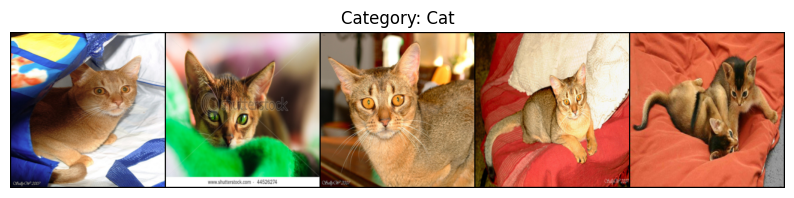

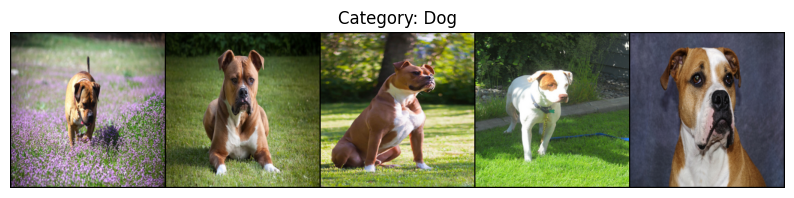

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from collections import defaultdict

# 라벨 해석 함수: 0 -> Cat, 1 -> Dog
def label_to_str(label):
    return "Cat" if label == 0 else "Dog"

# 카테고리별로 n개의 샘플 이미지를 수집하여 시각화하는 함수
def visualize_by_category(dataset, n_samples=5, cmap=None):
    samples = defaultdict(list)
    # 데이터셋을 순회하면서 각 카테고리별로 n_samples 개씩 수집
    for img, label in dataset:
        if len(samples[label]) < n_samples:
            samples[label].append(img)
        # 두 카테고리 모두 n_samples가 모이면 종료
        if len(samples) == 2 and all(len(imgs) >= n_samples for imgs in samples.values()):
            break

    # 수집된 각 카테고리별로 이미지 그리드 생성 및 시각화
    for label, imgs in samples.items():
        # make_grid를 사용하기 전에 각 이미지의 크기가 동일한지 확인합니다.
        grid_img = torchvision.utils.make_grid(imgs, nrow=n_samples, padding=2)
        plt.figure(figsize=(n_samples * 2, 4))
        # (C, H, W) -> (H, W, C)
        plt.imshow(grid_img.permute(1, 2, 0).numpy(), cmap=cmap)
        plt.title(f"Category: {label_to_str(label)}")
        plt.axis("off")
        plt.show()

# OxfordIIITPet 데이터셋 로드 (split="trainval" 사용)
dataset = torchvision.datasets.OxfordIIITPet(
    root="data",
    download=True,
    target_types="binary-category",  # 0: Cat, 1: Dog
    split="trainval",
    transform=transforms.Compose([
        transforms.Resize((256, 256)),  # 모든 이미지를 256x256 크기로 변환
        transforms.ToTensor()
    ])
)

# 카테고리별로 5개의 샘플 이미지 시각화
visualize_by_category(dataset, n_samples=5, cmap=None)


### 출처
- vgg-16 :  https://pytorch.org/vision/0.8/_modules/torchvision/models/vgg.html

